<a href="https://colab.research.google.com/github/i-malur/bootcamp-dados-desafio-python-3/blob/main/%5BOFICIAL%5D_Bootcamp_Modulo8_Probabilidade_e_Amostragem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

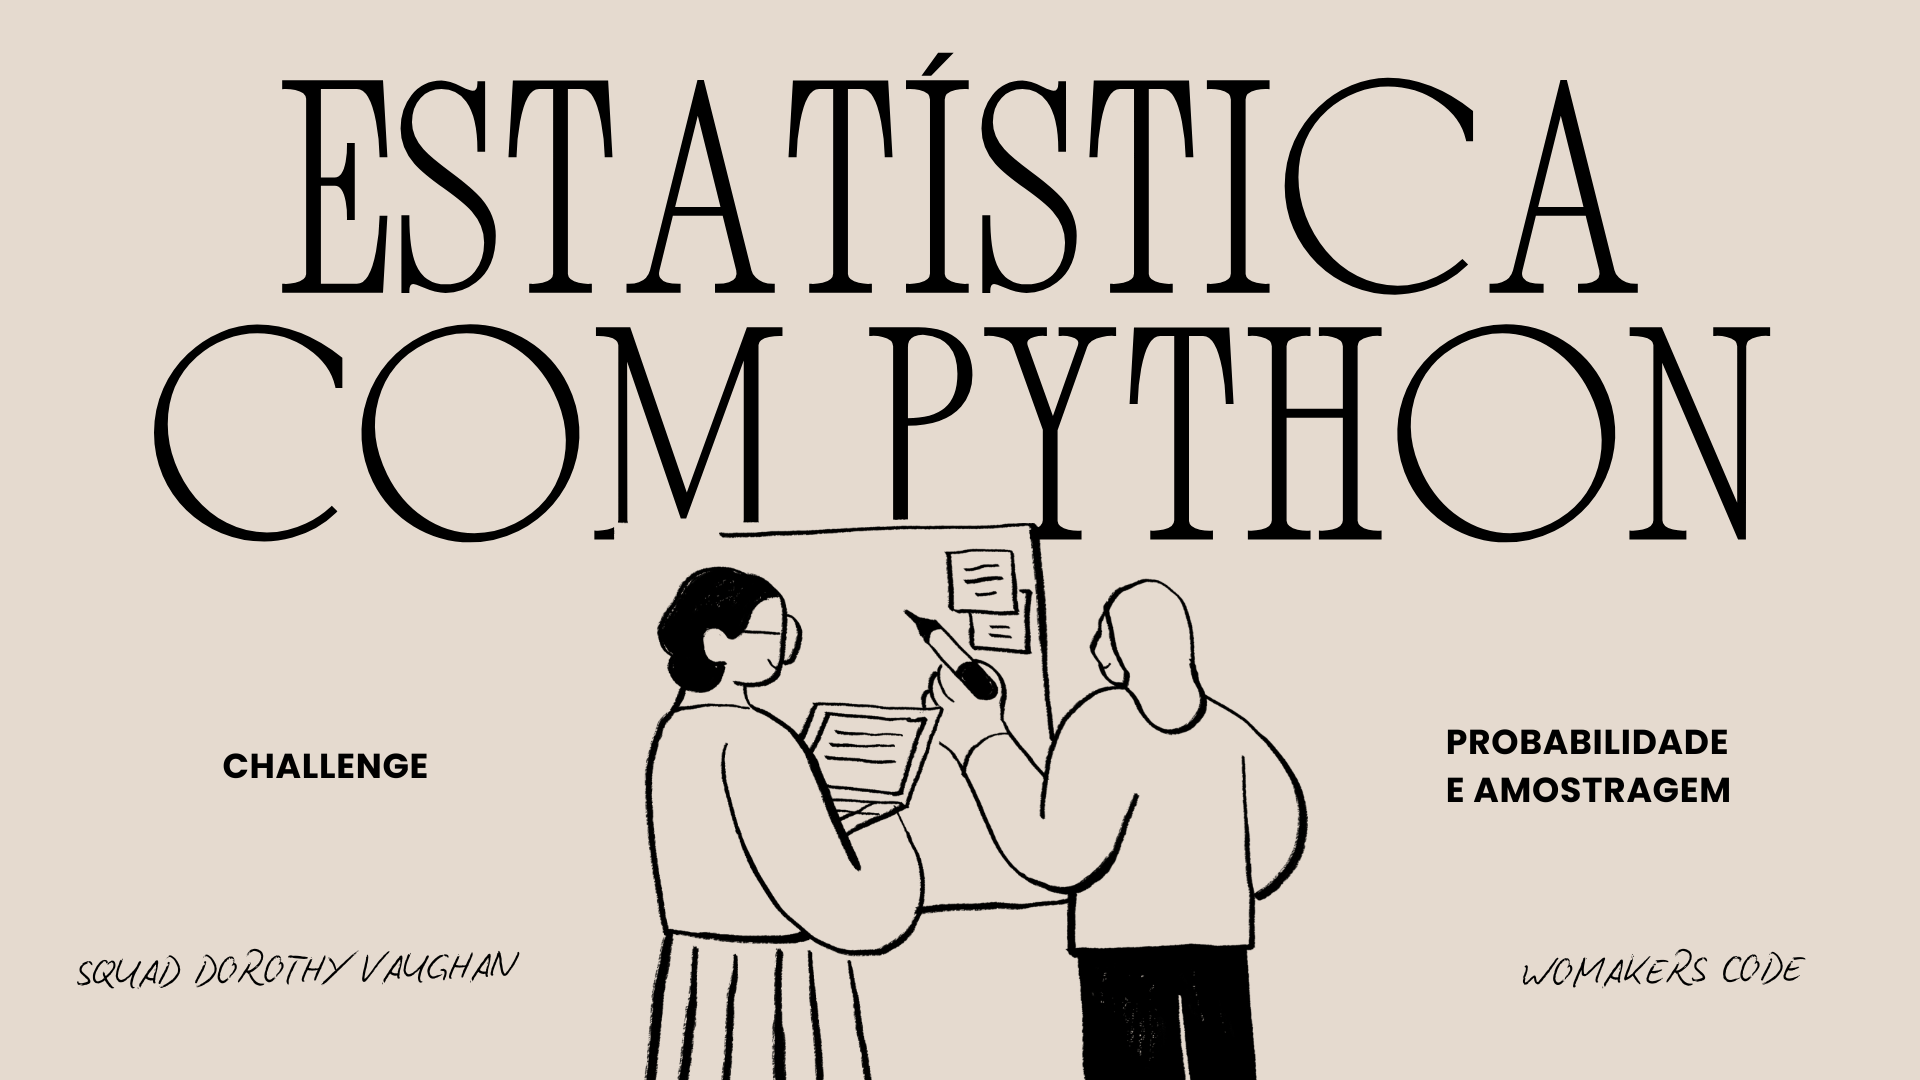

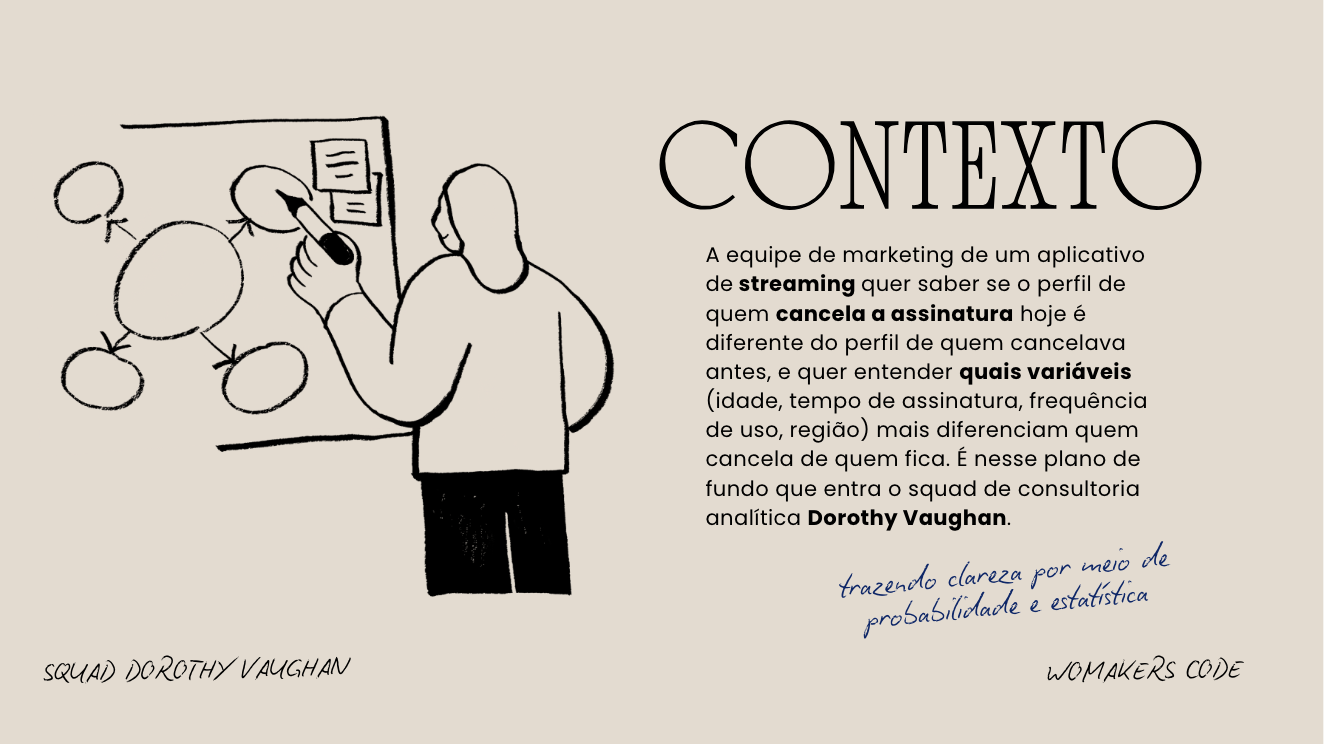

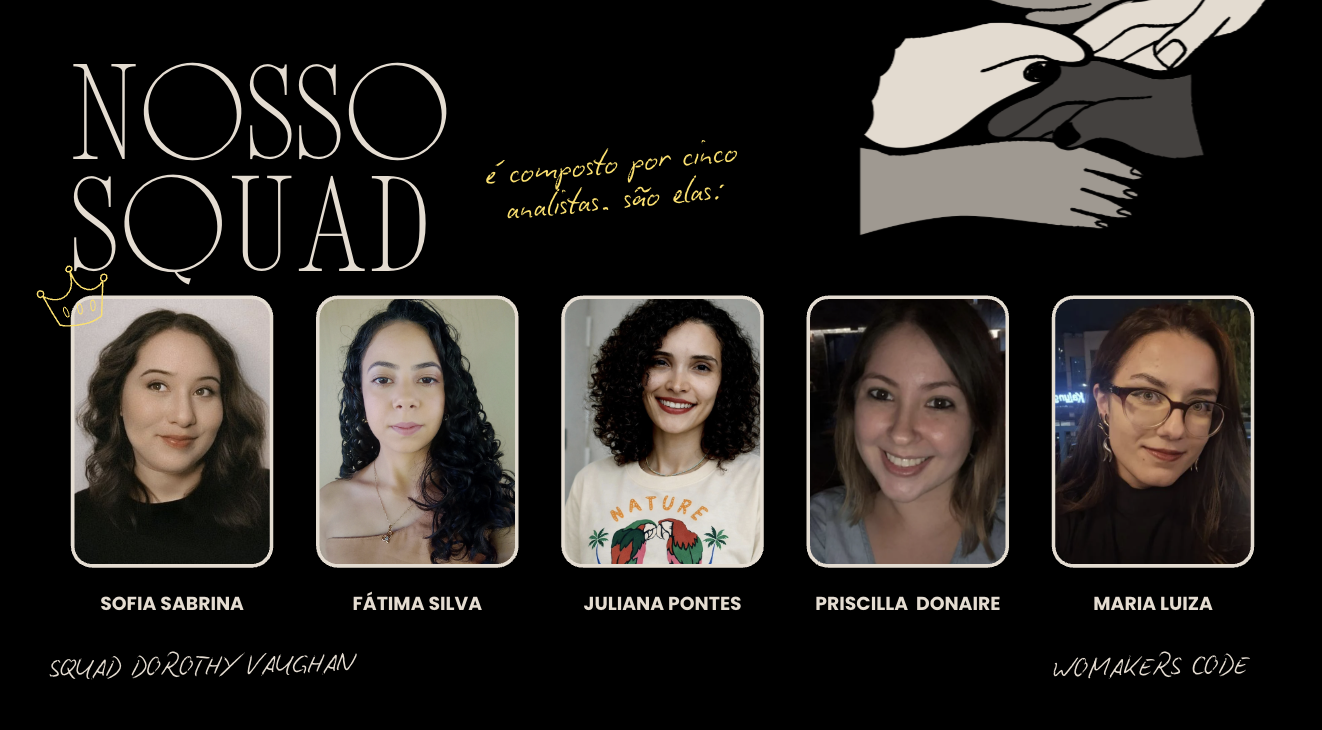

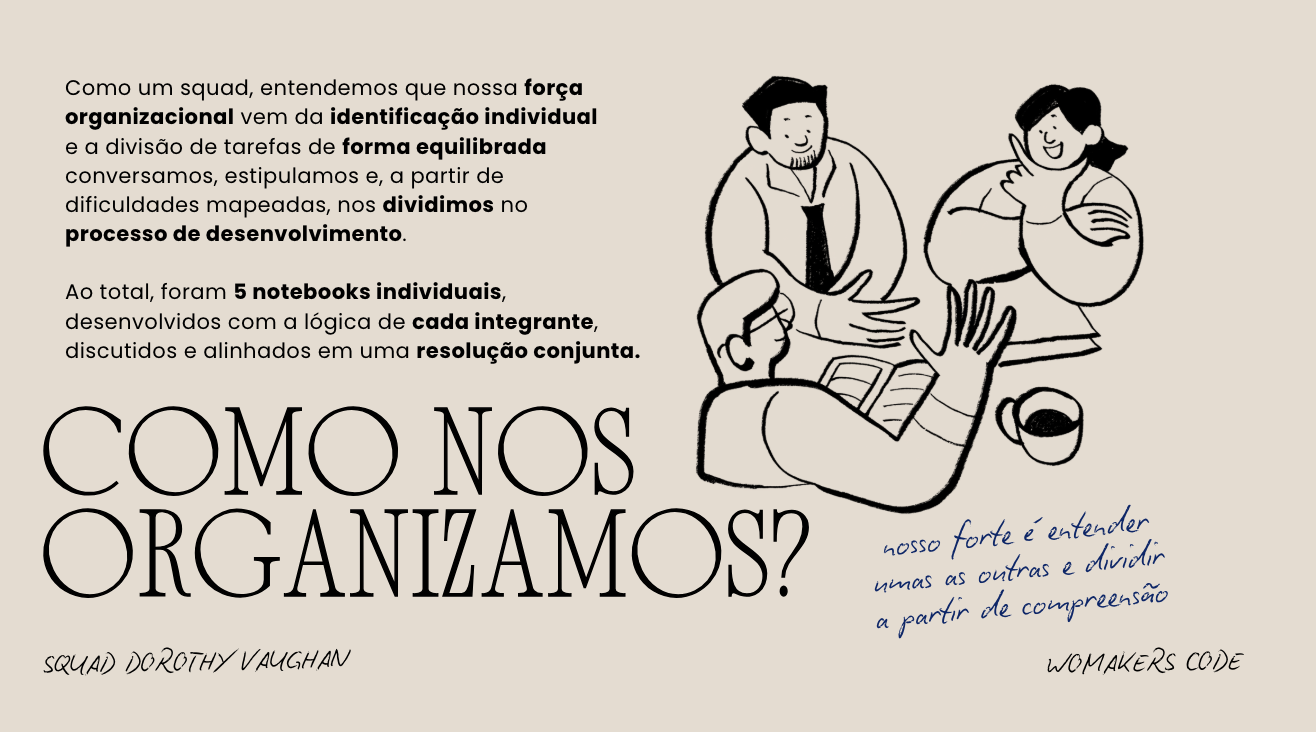

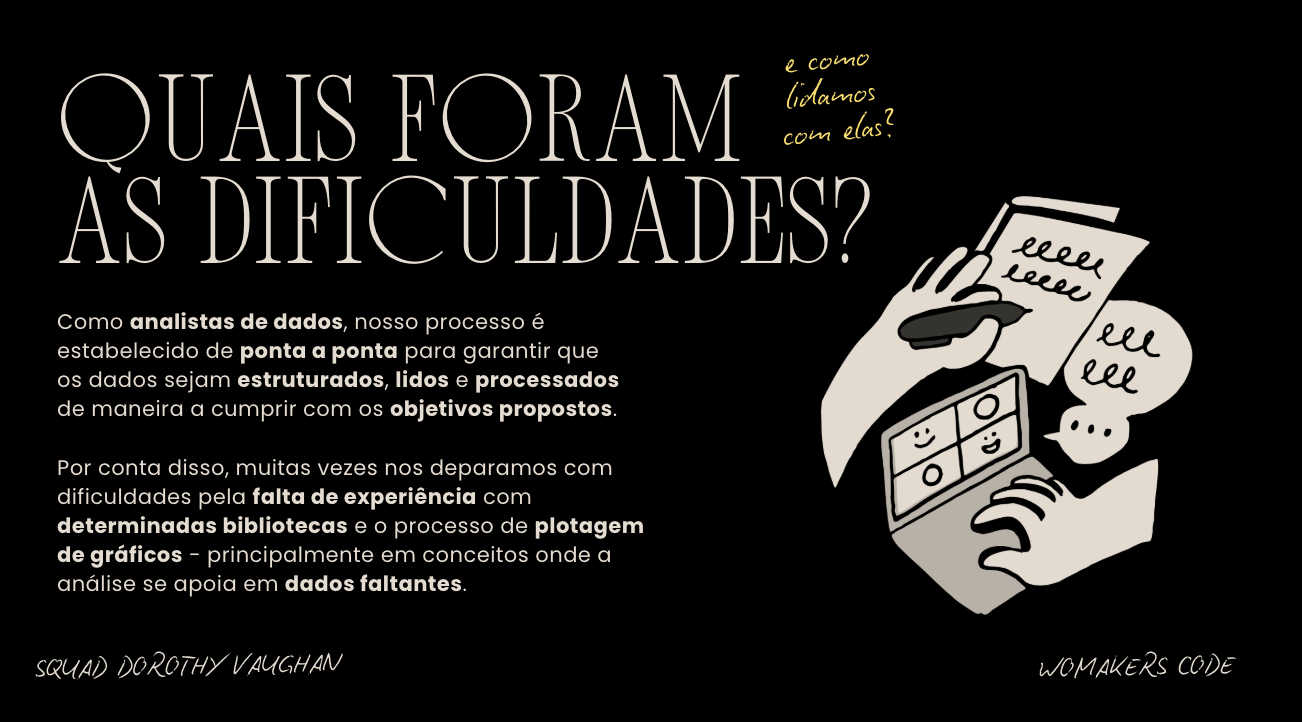

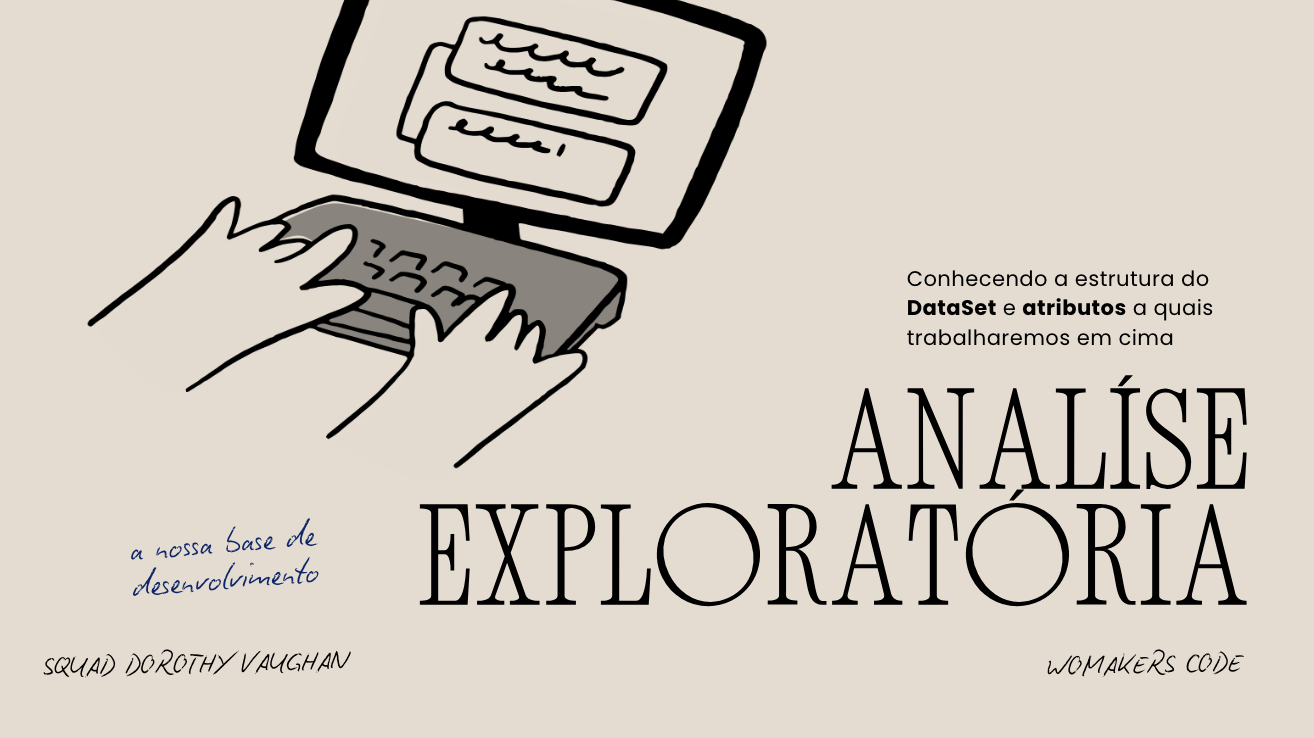

# Configuração de Ambiente

In [ ]:
# Import das Bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import chi2_contingency, ttest_ind
import math

In [ ]:
# Import do DataSet

url = 'https://raw.githubusercontent.com/Squad-Dorothy-Vaughan/Challenge-Probabilidade-Amostragem/refs/heads/main/clientes.csv'
df_clientes = pd.read_csv(url)

# Reconhecimento do DataSet

In [ ]:
display(df_clientes.head())

print('Dimensões da base:', df_clientes.shape)
print('\nInformações da base:')

df_clientes.info()
print('\nValores ausentes:')
print(df_clientes.isnull().sum())
print('\nSituação dos clientes:')
print(df_clientes['cancelou'].value_counts())

,cliente_id,idade,tempo_assinatura_meses,frequencia_uso_mensal,regiao,mensalidade,cancelou
0,1,56,30,27,Centro-Oeste,96.03,1
1,2,69,11,2,Norte,91.22,0
2,3,46,58,21,Sul,56.45,0
3,4,32,55,1,Norte,69.61,0
4,5,60,28,28,Sul,42.19,0


Dimensões da base: (200, 7)

Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cliente_id              200 non-null    int64  
 1   idade                   200 non-null    int64  
 2   tempo_assinatura_meses  200 non-null    int64  
 3   frequencia_uso_mensal   200 non-null    int64  
 4   regiao                  200 non-null    object 
 5   mensalidade             200 non-null    float64
 6   cancelou                200 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 11.1+ KB

Valores ausentes:
cliente_id                0
idade                     0
tempo_assinatura_meses    0
frequencia_uso_mensal     0
regiao                    0
mensalidade               0
cancelou                  0
dtype: int64

Situação dos clientes:
cancelou
0    144
1     56
Name: count, dtype: int64


In [ ]:
# Filtrando apenas os clientes que cancelaram
df_cancelados = df_clientes[df_clientes['cancelou'] == 1]

# Cancelaram com até 6 meses de assinatura
df_cancelamento_recente = df_cancelados[df_cancelados['tempo_assinatura_meses'] <= 6]

# Cancelaram com mais de 24 meses de assinatura
df_cancelamento_antigo = df_cancelados[df_cancelados['tempo_assinatura_meses'] > 24]

print('Cancelados com até 6 meses:', len(df_cancelamento_recente))
print('Cancelados com mais de 24 meses:', len(df_cancelamento_antigo))

Cancelados com até 6 meses: 9
Cancelados com mais de 24 meses: 32


In [ ]:
# Criar uma coluna que identifica os perfis de cancelamento
df_cancelados = df_cancelados.copy()
df_cancelados['grupo_cancelamento'] = 'Entre 7 e 24 meses'

df_cancelados.loc[
    df_cancelados['tempo_assinatura_meses'] <= 6, 'grupo_cancelamento'
] = 'Até 6 meses'

df_cancelados.loc[
    df_cancelados['tempo_assinatura_meses'] > 24, 'grupo_cancelamento'
] = 'Mais de 24 meses'

display(df_cancelados[[
    'idade', 'tempo_assinatura_meses', 'frequencia_uso_mensal',
    'regiao', 'mensalidade', 'grupo_cancelamento'
]])

,idade,tempo_assinatura_meses,frequencia_uso_mensal,regiao,mensalidade,grupo_cancelamento
0,56,30,27,Centro-Oeste,96.03,Mais de 24 meses
17,20,6,28,Norte,33.01,Até 6 meses
19,70,27,14,Nordeste,85.80,Mais de 24 meses
22,61,33,3,Sudeste,69.07,Mais de 24 meses
27,50,15,29,Norte,22.11,Entre 7 e 24 meses
28,29,59,17,Nordeste,50.12,Mais de 24 meses
29,39,54,14,Sudeste,84.84,Mais de 24 meses
31,42,32,3,Sul,32.03,Mais de 24 meses
32,66,24,28,Nordeste,67.53,Entre 7 e 24 meses
35,45,49,29,Centro-Oeste,87.37,Mais de 24 meses


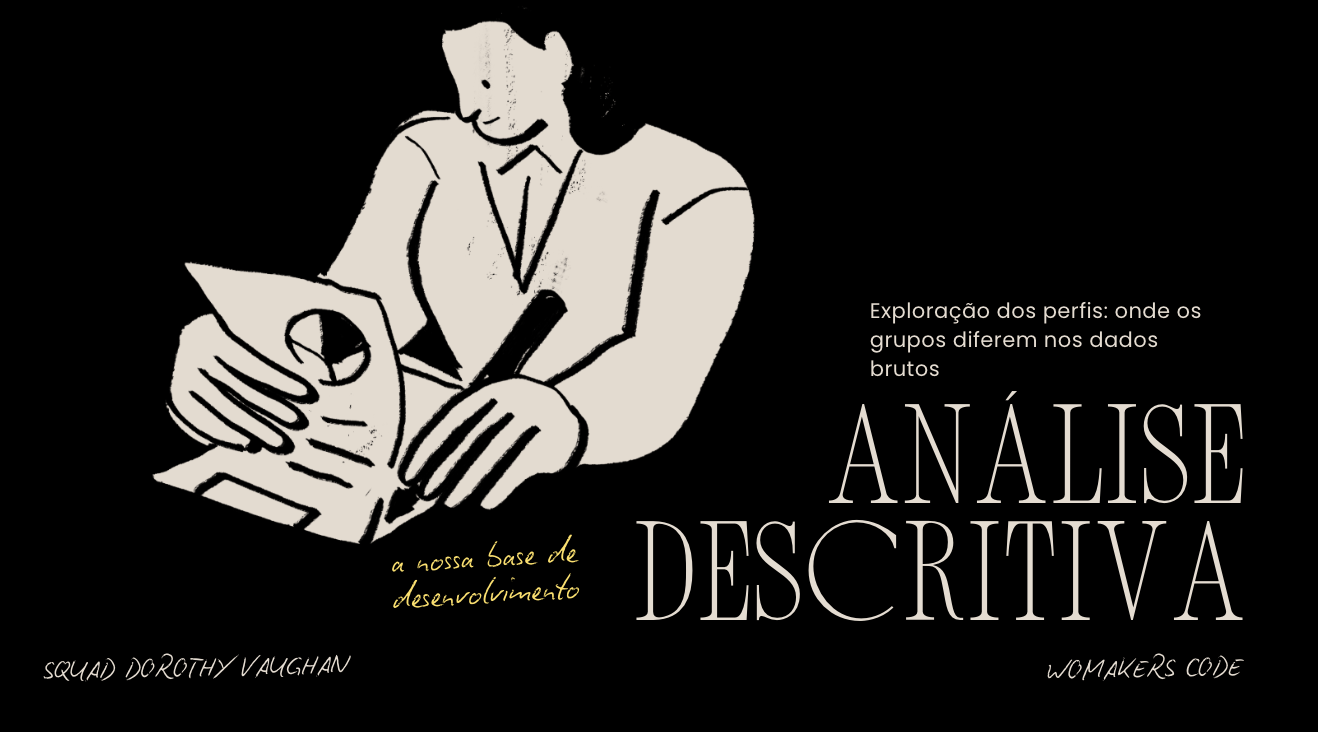

In [ ]:
# Comparando as médias das variáveis numéricas entre os dois grupos.
colunas_numericas = ['idade', 'tempo_assinatura_meses', 'frequencia_uso_mensal', 'mensalidade']

comparacao = pd.DataFrame({
    'Cancelamento até 6 meses':   df_cancelamento_recente[colunas_numericas].mean(),
    'Cancelamento após 24 meses': df_cancelamento_antigo[colunas_numericas].mean()
})

display(comparacao.round(2))

,Cancelamento até 6 meses,Cancelamento após 24 meses
idade,40.89,44.25
tempo_assinatura_meses,3.22,43.38
frequencia_uso_mensal,11.56,16.06
mensalidade,60.36,60.88


Observamos diferenças nas médias, especialmente na frequência de uso mensal. Porém, antes de qualquer conclusão, precisamos testar se essas diferenças são **estatisticamente significativas** — o grupo de cancelamentos recentes tem apenas 9 clientes - limita o poder dos testes.

A seguir, cada variável separadamente para facilitar a comparação visual entre os grupos:

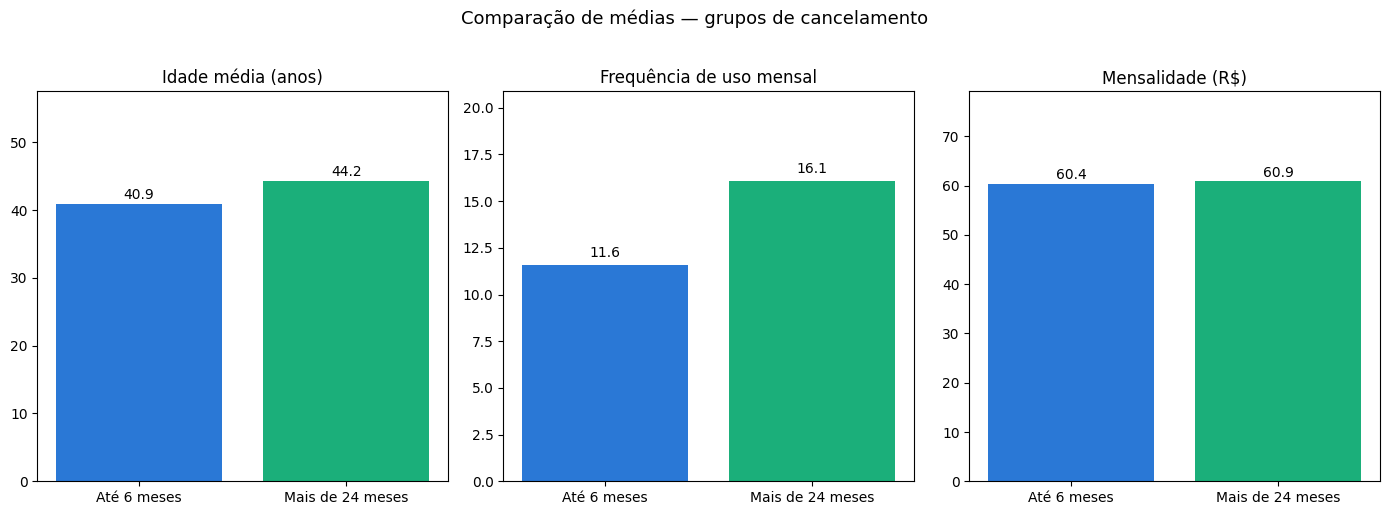

In [ ]:
# Gráfico de barras separados por variável

medias = pd.DataFrame({
    'Até 6 meses':      df_cancelamento_recente[['idade', 'frequencia_uso_mensal', 'mensalidade']].mean(),
    'Mais de 24 meses': df_cancelamento_antigo[['idade', 'frequencia_uso_mensal', 'mensalidade']].mean()
})

variaveis = ['idade', 'frequencia_uso_mensal', 'mensalidade']
titulos   = ['Idade média (anos)', 'Frequência de uso mensal', 'Mensalidade (R$)']
cores     = ['#2a78d6', '#1baf7a']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, titulo in zip(axes, variaveis, titulos):
    valores = medias.loc[col]
    barras  = ax.bar(valores.index, valores.values, color=cores)
    ax.set_title(titulo)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, valores.max() * 1.3)
    for barra in barras:
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.3,
            f'{barra.get_height():.1f}',
            ha='center', va='bottom', fontsize=10
        )

plt.suptitle('Comparação de médias — grupos de cancelamento', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

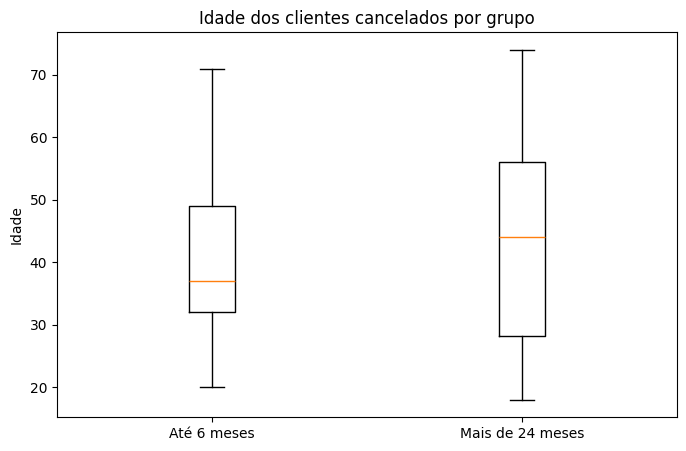

In [ ]:
# Boxplot de idade por grupo
plt.figure(figsize=(8, 5))
plt.boxplot(
    [df_cancelamento_recente['idade'], df_cancelamento_antigo['idade']],
    tick_labels=['Até 6 meses', 'Mais de 24 meses']
)
plt.title('Idade dos clientes cancelados por grupo')
plt.ylabel('Idade')
plt.show()

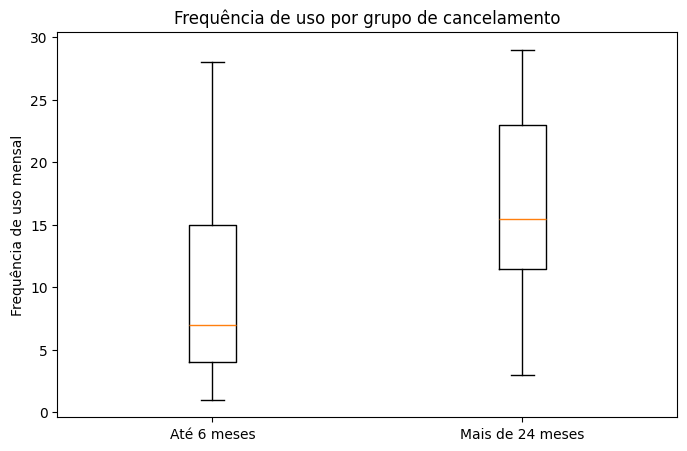

In [ ]:
# Boxplot de frequência de uso por grupo
plt.figure(figsize=(8, 5))
plt.boxplot(
    [df_cancelamento_recente['frequencia_uso_mensal'], df_cancelamento_antigo['frequencia_uso_mensal']],
    tick_labels=['Até 6 meses', 'Mais de 24 meses']
)
plt.title('Frequência de uso por grupo de cancelamento')
plt.ylabel('Frequência de uso mensal')
plt.show()

,Até 6 meses (%),Mais de 24 meses (%)
regiao,,
Centro-Oeste,44.44,21.88
Sudeste,44.44,12.50
Norte,11.11,15.62
Nordeste,0.00,31.25
Sul,0.00,18.75


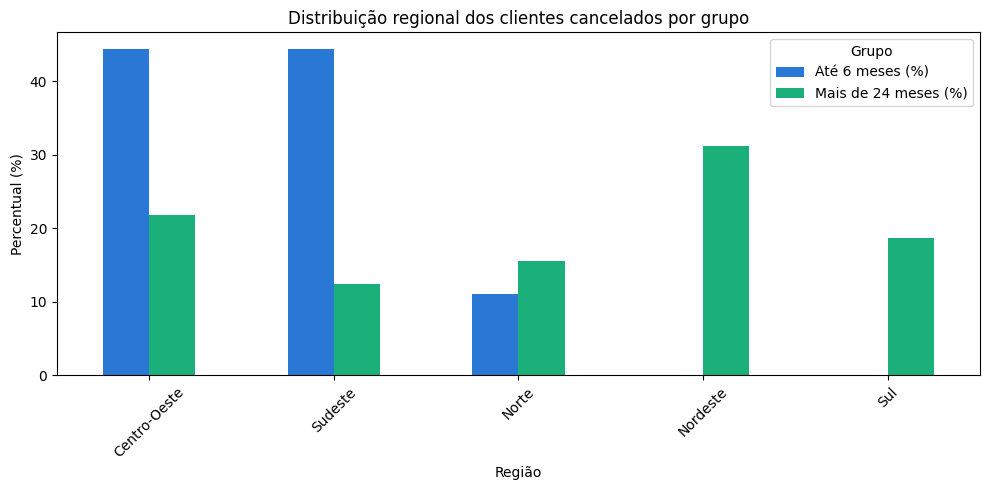

In [ ]:
# Comparação regional entre grupos (percentual)
regiao_recente = (
    df_cancelamento_recente['regiao']
    .value_counts(normalize=True).mul(100).round(2)
)

regiao_antigo = (
    df_cancelamento_antigo['regiao']
    .value_counts(normalize=True).mul(100).round(2)
)

comparacao_regiao = pd.concat(
    [regiao_recente, regiao_antigo], axis=1
).fillna(0)
comparacao_regiao.columns = ['Até 6 meses (%)', 'Mais de 24 meses (%)']

display(comparacao_regiao)

comparacao_regiao.plot(kind='bar', figsize=(10, 5), color=['#2a78d6', '#1baf7a'])
plt.title('Distribuição regional dos clientes cancelados por grupo')
plt.xlabel('Região')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=45)
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

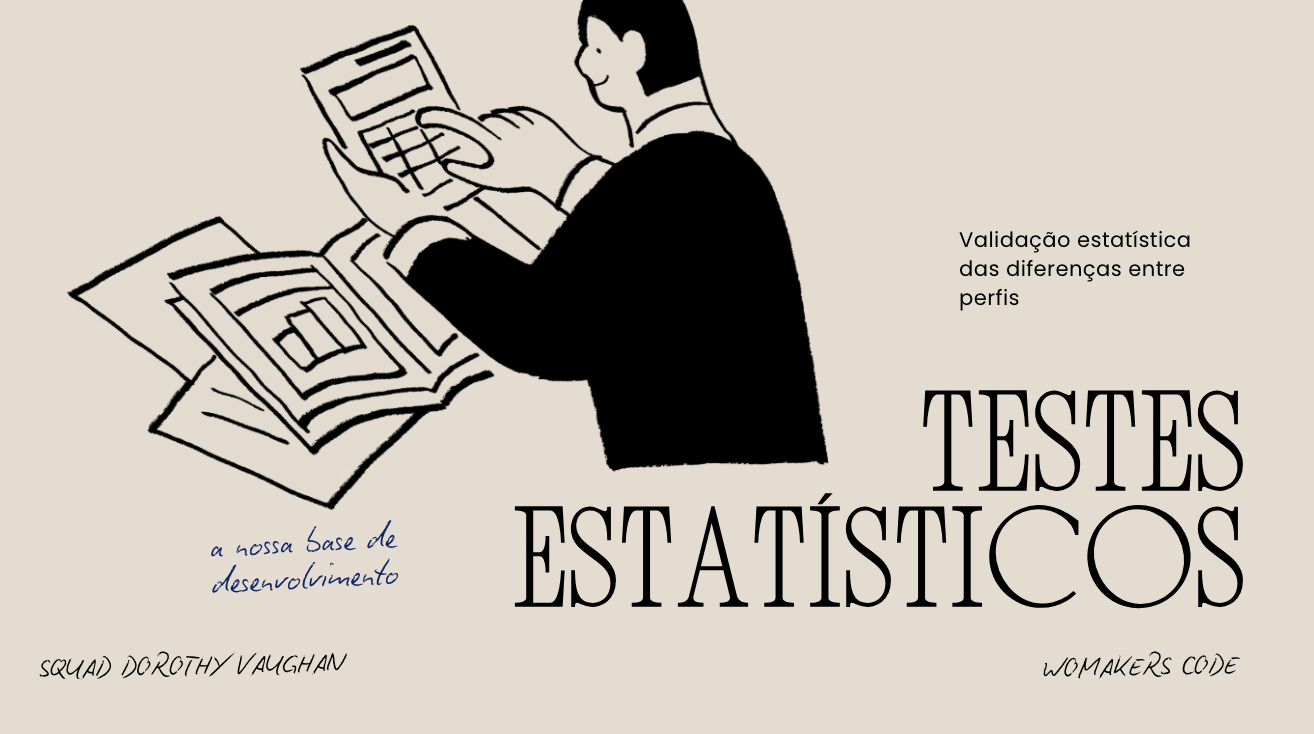

In [ ]:
# Teste t entre grupos de cancelados: recentes (≤ 6m) vs antigos (> 24m)
print("Testes t — Cancelamentos recentes (≤ 6m) vs antigos (> 24m)\n")
print(f"{'Variável':<30} {'Estatística t':>14} {'p-valor':>10}  Resultado")
print("-" * 72)

for col in ['idade', 'frequencia_uso_mensal', 'mensalidade']:
    t, p = ttest_ind(
        df_cancelamento_recente[col],
        df_cancelamento_antigo[col],
        equal_var=False
    )
    resultado = "Significativo" if p < 0.05 else "Não significativo"
    print(f"{col:<30} {t:>14.4f} {p:>10.4f}  {resultado}")

Testes t — Cancelamentos recentes (≤ 6m) vs antigos (> 24m)

Variável                        Estatística t    p-valor  Resultado
------------------------------------------------------------------------
idade                                 -0.5292     0.6058  Não significativo
frequencia_uso_mensal                 -1.2427     0.2400  Não significativo
mensalidade                           -0.0702     0.9448  Não significativo


Nenhuma variável numérica apresentou diferença estatisticamente significativa entre os dois grupos (p > 0,05 em todos os casos).

**Importante:** isso não significa que as diferenças não existam na população real. Com apenas 9 clientes no grupo de cancelamentos recentes, o teste não tem **poder estatístico** suficiente para detectar diferenças com confiança. Uma amostra maior poderia revelar padrões que aqui ficam ocultos.



In [ ]:
# Qui-quadrado — distribuição regional entre os dois grupos de cancelados
tabela_grupos = pd.crosstab(
    pd.Categorical(
        ['Recente'] * len(df_cancelamento_recente) +
        ['Antigo']  * len(df_cancelamento_antigo)
    ),
    pd.concat([
        df_cancelamento_recente['regiao'],
        df_cancelamento_antigo['regiao']
    ])
)

chi2, p, dof, _ = chi2_contingency(tabela_grupos)

print("Qui-quadrado — distribuição regional entre grupos de cancelados")
print(f"χ² = {chi2:.4f}  |  p-valor = {p:.4f}  |  graus de liberdade = {dof}")
print()
if p < 0.05:
    print("Resultado: há diferença significativa na distribuição regional entre os grupos.")
else:
    print("Resultado: não há diferença significativa na distribuição regional entre os grupos.")

Qui-quadrado — distribuição regional entre grupos de cancelados
χ² = 9.6051  |  p-valor = 0.0476  |  graus de liberdade = 4

Resultado: há diferença significativa na distribuição regional entre os grupos.


**Testes estatísticos — ativos vs cancelados (base completa)**

Ampliamos a análise para toda a base, comparando clientes que **mantiveram** a assinatura com **todos os que cancelaram**, independentemente do tempo de permanência.

Essa análise responde a uma pergunta diferente: existe alguma variável que, de forma geral, distingue quem fica de quem sai?



In [ ]:
# Criar coluna de situação
df_clientes['situacao'] = df_clientes['cancelou'].map({0: 'Manteve', 1: 'Cancelou'})

resumo_completo = (
    df_clientes
    .groupby('situacao')[['idade', 'tempo_assinatura_meses', 'frequencia_uso_mensal', 'mensalidade']]
    .agg(['mean', 'median', 'std'])
)

display(resumo_completo.round(2))

idade               tempo_assinatura_meses                \
           mean median    std                   mean median    std   
situacao                                                             
Cancelou  43.29   42.5  16.21                  29.66   29.5  18.79   
Manteve   46.03   45.5  15.96                  31.37   33.0  17.27   

         frequencia_uso_mensal              mensalidade                
                          mean median   std        mean median    std  
situacao                                                               
Cancelou                 15.71   15.0  9.08       57.33  53.64  23.41  
Manteve                  16.08   17.0  8.78       59.83  60.08  23.33

In [ ]:
# Teste t para cada variável numérica — ativos vs cancelados
print("Testes t — Ativos vs Cancelados (base completa)\n")
print(f"{'Variável':<30} {'Estatística t':>14} {'p-valor':>10}  Resultado")
print("-" * 72)

for col in ['idade', 'tempo_assinatura_meses', 'frequencia_uso_mensal', 'mensalidade']:
    grupo_cancelou = df_clientes.loc[df_clientes['cancelou'] == 1, col]
    grupo_manteve  = df_clientes.loc[df_clientes['cancelou'] == 0, col]

    t, p = ttest_ind(grupo_cancelou, grupo_manteve, equal_var=False)
    resultado = "Significativo" if p < 0.05 else "Não significativo"
    print(f"{col:<30} {t:>14.4f} {p:>10.4f}  {resultado}")

Testes t — Ativos vs Cancelados (base completa)

Variável                        Estatística t    p-valor  Resultado
------------------------------------------------------------------------
idade                                 -1.0785     0.2834  Não significativo
tempo_assinatura_meses                -0.5900     0.5566  Não significativo
frequencia_uso_mensal                 -0.2604     0.7951  Não significativo
mensalidade                           -0.6801     0.4980  Não significativo


Nenhuma variável numérica diferencia significativamente ativos de cancelados na base completa. Isso sugere que o cancelamento, nesta amostra, não está associado a um perfil demográfico ou comportamental claro.



In [ ]:
# Qui-quadrado — região vs cancelamento (base completa)
tabela_regiao = pd.crosstab(df_clientes['regiao'], df_clientes['cancelou'])

qui2, valor_p, graus_liberdade, esperados = chi2_contingency(tabela_regiao)

print('Tabela de contingência:')
display(tabela_regiao)

print(f'\nEstatística qui-quadrado: {qui2:.4f}')
print(f'Valor-p: {valor_p:.4f}')
print()
if valor_p < 0.05:
    print("Resultado: há associação significativa entre região e cancelamento.")
else:
    print("Resultado: não há evidência estatística de associação entre região e cancelamento.")

Tabela de contingência:


cancelou,0,1
regiao,,
Centro-Oeste,35,12
Nordeste,20,15
Norte,32,9
Sudeste,29,12
Sul,28,8



Estatística qui-quadrado: 5.3471
Valor-p: 0.2535

Resultado: não há evidência estatística de associação entre região e cancelamento.


In [ ]:
# Taxa de cancelamento por região
taxa_regiao = (
    df_clientes
    .groupby('regiao')['cancelou']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count': 'Total', 'sum': 'Cancelamentos', 'mean': 'Taxa'})
)
taxa_regiao['Taxa (%)'] = (taxa_regiao['Taxa'] * 100).round(2)
display(taxa_regiao)

,Total,Cancelamentos,Taxa,Taxa (%)
regiao,,,,
Centro-Oeste,47,12,0.255319,25.53
Nordeste,35,15,0.428571,42.86
Norte,41,9,0.219512,21.95
Sudeste,41,12,0.292683,29.27
Sul,36,8,0.222222,22.22


Embora o Nordeste apresente a maior taxa descritiva de cancelamento, o teste qui-quadrado (p ≈ 0,25) não confirma que essa diferença seja estatisticamente significativa. Não é adequado criar estratégias regionais definitivas com base apenas nos números descritivos sem suporte estatístico.

**Análise complementar — cancelamento por faixa de uso**

Para explorar melhor o comportamento de uso, dividimos os clientes em quatro faixas com base na frequência mensal (quartis) e calculamos a taxa de cancelamento em cada faixa.


In [ ]:
df_clientes['faixa_uso'] = pd.qcut(
    df_clientes['frequencia_uso_mensal'],
    q=4,
    labels=['Uso muito baixo', 'Uso baixo', 'Uso médio', 'Uso alto'],
    duplicates='drop'
)

taxa_por_uso = (
    df_clientes
    .groupby('faixa_uso', observed=False)['cancelou']
    .mean()
    .mul(100)
)

display(taxa_por_uso.round(2))

,cancelou
faixa_uso,
Uso muito baixo,32.08
Uso baixo,28.30
Uso médio,17.78
Uso alto,32.65


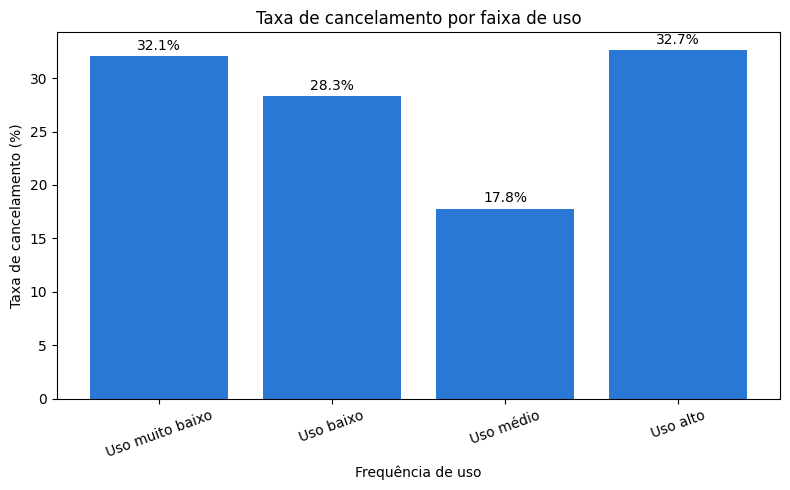

In [ ]:
plt.figure(figsize=(8, 5))
barras = plt.bar(taxa_por_uso.index, taxa_por_uso.values, color='#2a78d6')
plt.title('Taxa de cancelamento por faixa de uso')
plt.xlabel('Frequência de uso')
plt.ylabel('Taxa de cancelamento (%)')
plt.xticks(rotation=20)

for barra, valor in zip(barras, taxa_por_uso.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.3,
        f'{valor:.1f}%',
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()

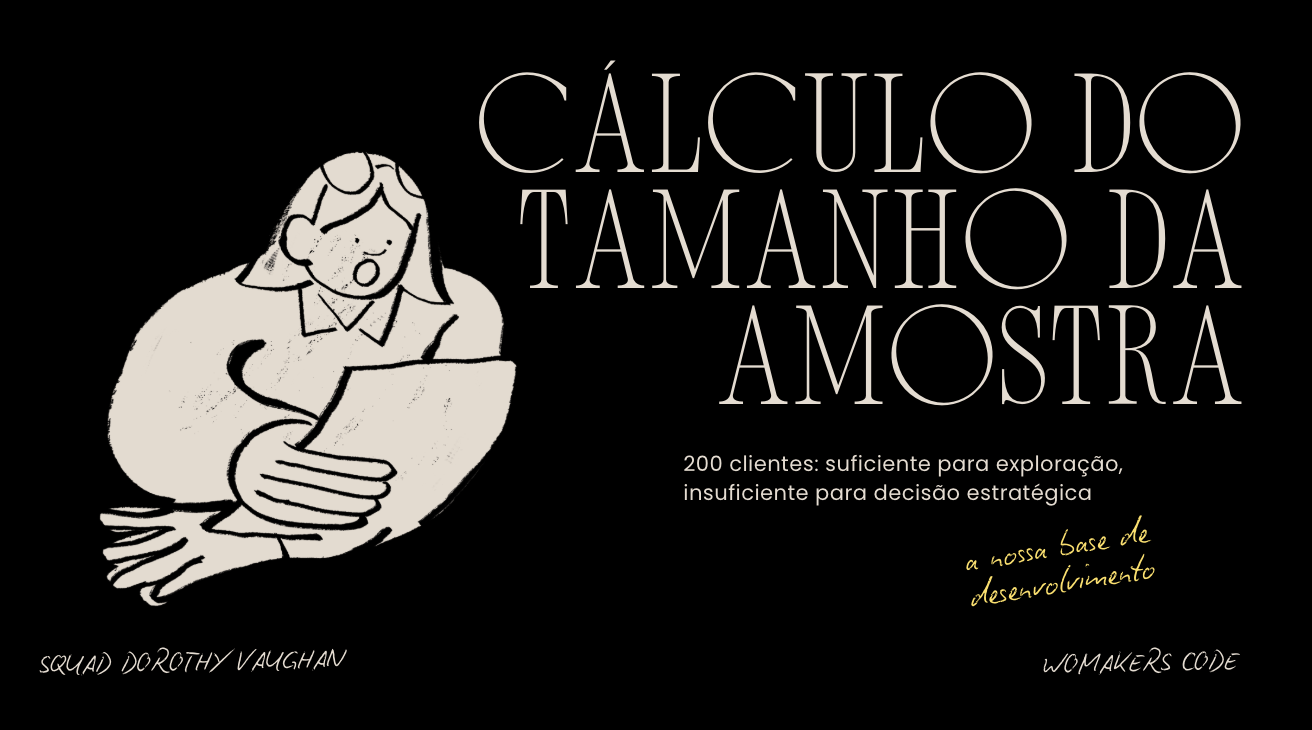


Os dados fornecidos são apenas uma **amostra** da base real de clientes. Suponha que a população verdadeira seja de **100.000 clientes**.

Queremos saber: qual tamanho de amostra é necessário para atingir **95% de confiança** com 2% de margem de erro e 10% de margem de erro



In [ ]:
N = 100_000
z = 1.96
p = 0.5

def tamanho_amostra(N, z, p, margem_erro):
    n0 = (z**2 * p * (1 - p)) / margem_erro**2
    n_corrigido = n0 / (1 + ((n0 - 1) / N))
    return math.ceil(n_corrigido)

amostra_2  = tamanho_amostra(N=N, z=z, p=p, margem_erro=0.02)
amostra_10 = tamanho_amostra(N=N, z=z, p=p, margem_erro=0.10)

print(f'Amostra necessária com margem de erro de  2%: {amostra_2:,}')
print(f'Amostra necessária com margem de erro de 10%: {amostra_10:,}')
print(f'Tamanho da base atual: {len(df_clientes):,}')
print()
print(f'Base suficiente para margem de  2%? {"Sim" if len(df_clientes) >= amostra_2  else "Não — faltam " + str(amostra_2  - len(df_clientes)) + " clientes"}')
print(f'Base suficiente para margem de 10%? {"Sim" if len(df_clientes) >= amostra_10 else "Não"}')

Amostra necessária com margem de erro de  2%: 2,345
Amostra necessária com margem de erro de 10%: 96
Tamanho da base atual: 200

Base suficiente para margem de  2%? Não — faltam 2145 clientes
Base suficiente para margem de 10%? Sim


**Interpretação dos resultados:**

Com margem de 2%, precisaríamos de mais de 11 vezes o tamanho da base atual. Com margem de 10%, nossa base é suficiente — mas conclusões com essa margem devem ser interpretadas com menor precisão.

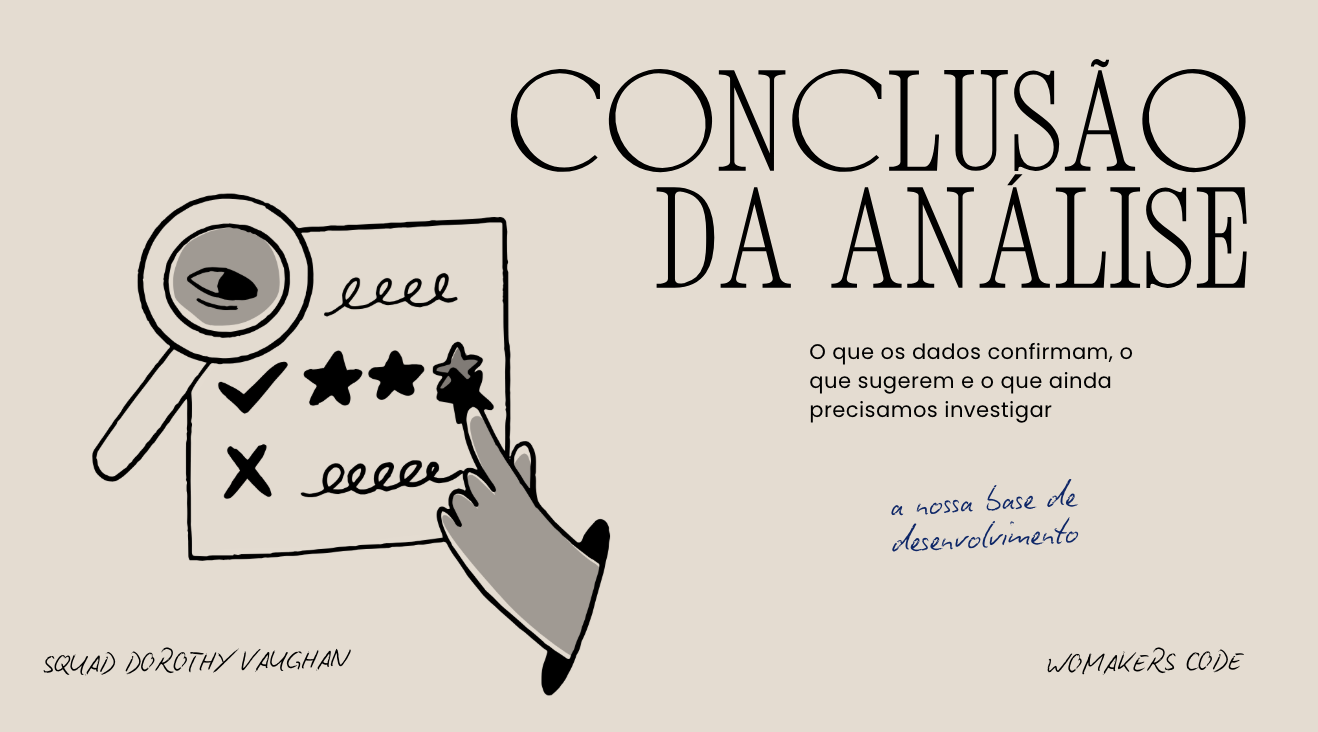


# O que os dados mostraram?

A análise comparou dois grupos de clientes que cancelaram a assinatura: os que saíram nos primeiros 6 meses (9 clientes) e os que permaneceram por mais de 24 meses antes de cancelar (32 clientes).

Na comparação descritiva, o grupo de cancelamentos recentes apresentou frequência média de uso inferior (11,6 vs 16,1 acessos/mês) e está mais concentrado nas regiões Centro-Oeste e Sudeste. O grupo de cancelamentos antigos, por sua vez, tem distribuição regional mais ampla, com o Nordeste como região mais representada.

Um único achado foi confirmado estatisticamente: a distribuição regional difere entre os grupos de cancelados.

**Os teste estatistico não identificou diferenças significativas em nenhuma das variáveis analisadas** entre os dois grupos — nem em idade, frequência de uso e mensalidade.

O mesmo resultado se repete na comparação entre ativos e cancelados na base completa: nenhuma variável numérica nem a região apresentou associação estatisticamente significativa com o cancelamento.



# Por que os testes não foram significativos?

O principal fator limitante é o **tamanho dos grupos**. Com apenas 9 clientes no grupo de cancelamentos recentes, os testes não têm poder estatístico suficiente para detectar diferenças reais, mesmo que elas existam na população. Os resultados descritivos (como a diferença na frequência de uso) podem ser indicativos de tendências reais, mas não podem ser confirmados com esta amostra.





# O que a análise de amostragem revelou?

Considerando uma população de 100.000 clientes:
- Para conclusões com **margem de erro de 2%** e 95% de confiança, seriam necessários aproximadamente **2.345 clientes** — a base atual é insuficiente.
- Para conclusões com **margem de erro de 10%**, seriam necessários apenas **96 clientes** — a base atual é suficiente para esse nível de precisão.

Isso significa que as análises realizadas aqui são válidas como exploração inicial, mas as conclusões devem ser tratadas com cautela até que se disponha de uma base maior.

# Recomendações

**Investigar Centro-Oeste, Sudeste e Nordeste:**
É o único achado confirmado estatisticamente. Vale enteder se há diferença de catálogo ou concorrência nessas regiões.

**Para retenção nos primeiros meses:**
Mesmo sem significância estatística, a diferença descritiva na frequência de uso sugere que clientes que saem cedo usam menos o serviço. Recomenda-se investir no processo de integração (onboarding), com recomendações personalizadas de conteúdo, tutoriais e comunicações nos primeiros 30 e 60 dias.

**Para recuperação de clientes antigos:**
Clientes que permaneceram por mais de dois anos antes de cancelar já conhecem o serviço. Campanhas de retorno com novidades de conteúdo, benefícios temporários e pesquisas de motivo de cancelamento são mais indicadas para esse perfil.

**Para monitoramento contínuo:**
Implementar análise de coorte acompanhando a retenção nos marcos de 30, 90, 180 dias e 1 ano permitiria identificar com precisão em qual momento a perda de clientes é mais crítica.

**Para ampliar a base de análise:**
A coleta de variáveis adicionais como: data exata de cancelamento, motivo do cancelamento, tipo de plano, dispositivo utilizado e histórico de atendimento,tornaria análises futuras muito mais precisas. Além disso, ampliar a base para ao menos 2.345 clientes permitiria trabalhar com margem de erro de 2%, o que daria suporte estatístico mais robusto para decisões estratégicas.